# Packages

In [1]:
from IPython import get_ipython
import os

In [2]:
# Matplotlib widget magic
if os.environ.get("GENERATING_NOTEBOOKS"):
    get_ipython().run_line_magic("matplotlib", "inline")
else:
    get_ipython().run_line_magic("matplotlib", "widget")

In [3]:
try:
    import cupy as xp
except ImportError:
    import numpy as xp

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
from cupyx.scipy.ndimage import shift as shiftcp

In [5]:
from libertem_holo.base.io import Results, InputData
from libertem_holo.base.reconstr import reconstruct_frame, reconstruct_bf, phase_offset_correction
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import ImageCorrelator
from libertem_holo.base.filters import clipped
from libertem_holo.base.unwrap import phase_unwrap

# Load hologram stacks

Data is loaded from dm3 or dm4 files directly into a 'data' object which contains the stack as well as metadata information such as the pixel size in meters, the total exposure time in seconds and the GMS tags.

In [6]:
# Reference stack
path = "/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/reconstr/stack_ref_minus.dm4"
data_ref = InputData.load_from_dm(path)

# Object stack
path = "/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/reconstr/stack_obj_minus.dm4"
data_obj = InputData.load_from_dm(path)

In [7]:
data_obj.pixelsize, data_obj.exposure_time, data_obj.shape

(1.4522670209407806e-10, np.float64(60.0), (30, 3838, 3710))

Text(0, 0.5, 'nm')

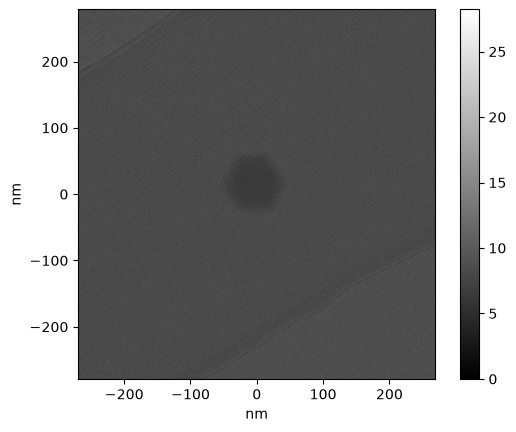

In [8]:
# Show one frame of the stack

frame = data_obj.data[0]
extent=(
    -data_obj.pixelsize*frame.shape[1]/2*1e9, data_obj.pixelsize*frame.shape[1]/2*1e9,
    -data_obj.pixelsize*frame.shape[0]/2*1e9, data_obj.pixelsize*frame.shape[0]/2*1e9,
)
plt.figure()
im = plt.imshow(
    frame, vmin=np.min(clipped(frame)), vmax=np.max(clipped(frame)),
    extent=extent, cmap='gray',
)
plt.colorbar()
plt.xlabel('nm')
plt.ylabel('nm')

# Hologram reconstruction parameters

The hologram reconstruction parameters are:

    - sideband position
    
    - sideband size
    
    - output shape
    
    - line filter for Fresnel fringes (length and width)
    
    - Butterworth filter order
    
The parameters are stored in the 'HoloParams' object. A convenient function 'from_hologram' calculates all parameters automatically with default values, but every parameter is editable. 

In [9]:
# One frame is passed as argument for the parameters determination, for example the first frame of the reference stack.

holoparams = HoloParams.from_hologram(data_ref.data[0], xp=xp)

CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [10]:
holoparams.sb_size, holoparams.sb_position, holoparams.out_shape

NameError: name 'holoparams' is not defined

In [11]:
# if necessary, we can force a sideband size, or output shape in the holoparams
# if the output shape does not respect the aspect ratio of the original hologram, 
# a warning is raised to warn the user that the pixel size will no longer be valid for 
# both x and y dimensions, continue at your own risk

holoparams = HoloParams.from_hologram(data_ref.data[0], xp=xp, sb_size=200, out_shape=(512, 512))

CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [12]:
holoparams.sb_size, holoparams.sb_position, holoparams.out_shape

NameError: name 'holoparams' is not defined

NameError: name 'holoparams' is not defined

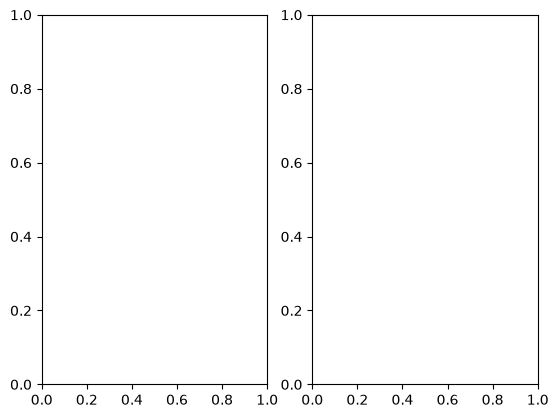

In [13]:
# we can visualise the aperture created to filter the FFT

fig, ax = plt.subplots(ncols=2)#, sharex=True, sharey=True)
aperture = xp.fft.fftshift(holoparams.aperture).get()
fft = xp.fft.fftshift(xp.fft.fft2(xp.asarray(data_obj.data[0]))).get()
#fft = xp.roll(fft, np.array(holoparams.sb_position_int).astype(np.int64), axis=(0, 1)).get()
#fft = fft[holoparams.slice_fft]

ax[0].imshow(np.log1p(np.abs(fft)), cmap='gray')
ax[1].imshow(aperture)

# Reconstruction of one frame

In [14]:
# before reconstructing the whole stack, it can be useful to check the reconstruction parameters
# by reconstructing one single frame and plotting the amplitude and phase of the complex wave.

# First the object wave is reconstructed
wave_obj = reconstruct_frame(
    data_obj.data[0], sb_pos=holoparams.sb_position, aperture=holoparams.aperture,
    slice_fft=holoparams.slice_fft, xp=xp
)

# Then the reference wave...
wave_ref = reconstruct_frame(
    data_ref.data[0], sb_pos=holoparams.sb_position, aperture=holoparams.aperture,
    slice_fft=holoparams.slice_fft, xp=xp
)

# ... and the reference wave is removed from the object wave to reduce distorsions
wave = wave_obj / wave_ref

NameError: name 'holoparams' is not defined

If you are using a GPU and the cupy library instead of numpy, the final wave must be transferred to CPU before plotting

In [15]:
wave = wave.get()

NameError: name 'wave' is not defined

The amplitude and phase images can then be extracted and plotted

In [16]:
amp = np.abs(wave)
phase = np.angle(wave)

fig, ax = plt.subplots(ncols=2)
ax[0].imshow(amp, vmin=np.min(clipped(amp)), vmax=np.max(clipped(amp)))
ax[1].imshow(phase)

NameError: name 'wave' is not defined

The bright field (centerband filtering) of the hologram can also be reconstructed. The same 'holoparams' can be used as well.

In [17]:
bf = reconstruct_bf(data_obj.data[0], aperture=holoparams.aperture, slice_fft=holoparams.slice_fft, xp=xp)

NameError: name 'holoparams' is not defined

In [18]:
# if using cupy
bf = bf.get()

NameError: name 'bf' is not defined

In [19]:
plt.figure()
plt.imshow(bf)

NameError: name 'bf' is not defined

<Figure size 640x480 with 0 Axes>

# Reconstruction stack

Now that we are satisfied with our reconstruction parameters, we can reconstruct a stack.

In [20]:
from libertem_holo.base.convenience import reconstruct_stack

In [21]:
%pdb off

Automatic pdb calling has been turned OFF


In [22]:
import cupy as cp

In [23]:
res = reconstruct_stack(stack=data_obj, stack_ref=data_ref, holoparams=None, xp=cp)

CUDARuntimeError: cudaErrorInsufficientDriver: CUDA driver version is insufficient for CUDA runtime version

In [24]:
phase = phase_unwrap(np.angle(res.complex_wave))

NameError: name 'res' is not defined

In [25]:
res.unwrapped_phase = phase

NameError: name 'phase' is not defined

`res` contains `complex_wave`, `unwrapped_phase`  and `brightfield`. Metadata can also be added.

It also contains metadata which include the effective pixel size after hologram reconstruction.

In [26]:
res.metadata

NameError: name 'res' is not defined

Additionnal metadata can be added as desired.

In [27]:
res.metadata['temperature'] = 300
res.metadata['sample'] = 'Magnetite nanocube'

NameError: name 'res' is not defined

In [28]:
res.metadata

NameError: name 'res' is not defined

# Phase ramp

Sometimes if the sideband is not perfectly centered or there are some distorsions from the microscope, a phase ramp can be observed across the phase image.

A function to remove this ramp can be used:

In [29]:
from libertem_holo.base.utils import remove_phase_ramp

A region-of-interest where no phase gradient is expected can be added as input.

In [30]:
def make_rect_fig(ax, rois):
    for roi in rois:
        ax.add_patch(plt.Rectangle(
            (roi[1].start, roi[0].start), roi[1].stop-roi[1].start, roi[0].stop-roi[0].start,
            edgecolor='red', facecolor='none', lw=2,
            ))

NameError: name 'res' is not defined

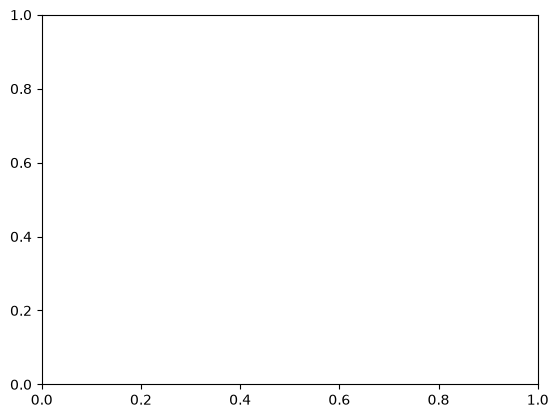

In [31]:
fig, ax = plt.subplots()
roi = np.s_[50:150, 250:400]
ax.imshow(res.unwrapped_phase)
make_rect_fig(ax, rois=[roi])


In [32]:
phase_t, _, _ = remove_phase_ramp(res.unwrapped_phase, roi=roi, method = 'gradient')
phase_t -= np.mean(phase_t[roi])

NameError: name 'res' is not defined

In [33]:
plt.figure()
plt.plot(res.unwrapped_phase[200, ...], label='Original phase')
plt.plot(phase_t[200, ...], label='After ramp removal')
plt.legend()

NameError: name 'res' is not defined

<Figure size 640x480 with 0 Axes>

The `res` object can be modified to accept the new phase easily.

In [34]:
res.unwrapped_phase = phase_t

NameError: name 'phase_t' is not defined

Finally, the dataset can be saved as a .npz file.

res.save(path + filename + ".npz")

# Phase unwrapping

Phase unwrapping can introduce a lot of artefacts due to low signal-to-noise ratio, hard edges, large phase gradient...  The basic `phase_unwrap` function is directly coming from the skimage package and can be used on a complex wave or a wrapped phase. Additionnal algorithms are also implement in the `unwrap` module based on quality guided unwrapping and least-square fitting unwrapping. However, the latter still introduces artefacts and should not be used for quantitative analysis of off-axis electron holography.

Quality based unwrapping:

In [35]:
from libertem_holo.base.unwrap import quality_unwrap, derivative_variance

In [36]:
phase_wrapped = np.angle(res.complex_wave)
quality_map = derivative_variance(phase_wrapped)
phase_unwrapped = quality_unwrap(phase_wrapped, quality=quality_map)

NameError: name 'res' is not defined

In [37]:
plt.figure()
plt.imshow(phase_unwrapped)

NameError: name 'phase_unwrapped' is not defined

<Figure size 640x480 with 0 Axes>

Least-square unwrapping:
COMING SOON

In [38]:
#from libertem_holo.base.unwrap import ls_unwrap

# Load and visualise a npz reconstructed dataset

In [39]:
data = Results.load("/storage/er-c-data/adhoc/libertem/libertem-test-data/dm/holo/align/minus.npz")

In [40]:
wave = data.complex_wave
amp = np.abs(wave)
phase = data.unwrapped_phase
bf = data.brightfield
pixel_size = data.metadata['effective_pixelsize'] # in meters !

In [41]:
extent = (
    0, phase.shape[1] * pixel_size*1e9,
    0, phase.shape[0] * pixel_size*1e9
)

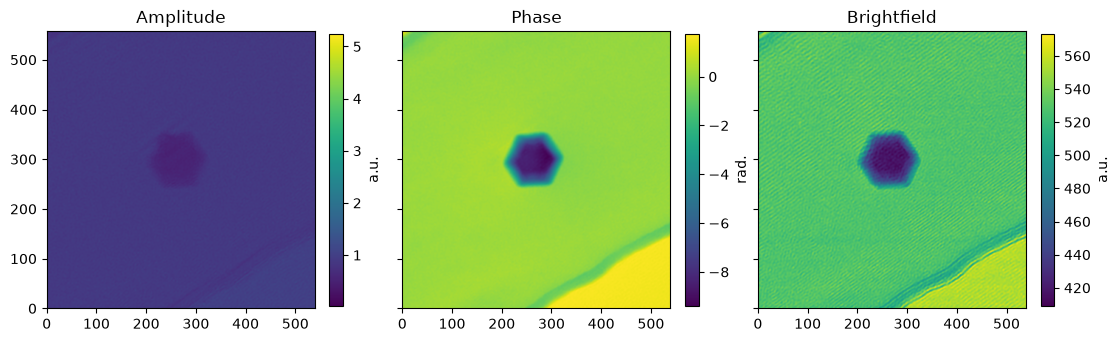

In [42]:
fig, ax = plt.subplots(ncols=3, sharex=True, sharey=True, figsize=(13, 5))
idx = 50
roi=np.s_[idx:-idx, idx:-idx]

im = ax[0].imshow(amp[roi], extent=extent, vmin=np.min(clipped(amp)), vmax=np.max(clipped(amp)))
ax[0].set_title('Amplitude')
plt.colorbar(im, fraction=0.046, label='a.u.')
im = ax[1].imshow(phase[roi], extent=extent)
ax[1].set_title('Phase')
plt.colorbar(im, fraction=0.046, label='rad.')
im = ax[2].imshow(bf[roi], extent=extent)
ax[2].set_title('Brightfield')
plt.colorbar(im, fraction=0.046, label='a.u.')